# Head

In [1]:
import pandas as pd
from pathlib import Path
home = Path.home()

test = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/test.tsv', sep='\t')
test

,doi,paper_id,abstract,annotation
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,A demonstration that cattle have been domestic...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,Evidence is presented for independent domestic...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,This paper shows how the identity-by-descent a...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,The pattern of linkage disequilibrium (LD) acr...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,The first paper to show the use of divergent i...
...,...,...,...,...
35631,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,This article describes the good manufacturing ...
35632,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,This study reports the generation of an orthog...
35633,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,This article shows that some diabetogenic T ce...
35634,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,This article describes the development of gene...


In [2]:
gemma3 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/gemma3.txt',
                          sep='\t', header=None, names=['gemma3'])
deepseek_r1 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/deepseek_r1.txt',
                          sep='\t', header=None, names=['deepseek_r1'])
gpt_oss = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/gpt_oss.txt',
                          sep='\t', header=None, names=['gpt_oss'])
llama4 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/llama4.txt',
                          sep='\t', header=None, names=['llama4'])
qwen3 = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/qwen3.txt',
                          sep='\t', header=None, names=['qwen3'], skip_blank_lines=False) # one blank line in file


In [3]:
df = test.join([gemma3, deepseek_r1, gpt_oss, llama4, qwen3])
df

,doi,paper_id,abstract,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reported here constitute a comprehens...,Identifies a major QTL on chromosome 4 underly...
...,...,...,...,...,...,...,...,...,...
35631,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,This article describes the good manufacturing ...,This study describes an efficient protocol for...,This study evaluates methods for isolating and...,The authors compare human T‑reg isolation stra...,These studies suggest that isolation and expan...,This study demonstrates that CD4+CD127lo/−CD25...
35632,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,This study reports the generation of an orthog...,Reference 48 describes the engineering of a sy...,This study describes the engineering of synthe...,Sockolosky et al. engineered an orthogonal IL‑...,This study demonstrates that orthogonal IL-2 a...,This work describes engineered synthetic IL-2 ...
35633,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,This article shows that some diabetogenic T ce...,Reference 51 shows that autoreactive T cells c...,This study identifies hybrid peptides as targe...,Delong et al. used mass‑spectrometry–based pep...,This study identifies an important mechanism u...,This study identifies autoimmune T cell recogn...
35634,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,This article describes the development of gene...,This work demonstrates that a combined strateg...,This study presents a novel strategy for enhan...,The authors used multiplex CRISPR editing to d...,This study presents a comprehensive strategy t...,This study reports a genome-editing strategy t...


In [4]:
df.isna().sum()

doi            0
paper_id       0
abstract       0
annotation     0
gemma3         0
deepseek_r1    0
gpt_oss        0
llama4         0
qwen3          1
dtype: int64

In [5]:
df['qwen3'] = df['qwen3'].fillna('')

In [6]:
for index in pd.read_csv(home / "projects/TLDR/dataset_description/invalid_entry_in_test.txt", sep='\t', header=None).values.flatten().tolist():
    df = df.drop(index-2)  # Adjusting for zero-based index
df

,doi,paper_id,abstract,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reported here constitute a comprehens...,Identifies a major QTL on chromosome 4 underly...
...,...,...,...,...,...,...,...,...,...
35631,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,This article describes the good manufacturing ...,This study describes an efficient protocol for...,This study evaluates methods for isolating and...,The authors compare human T‑reg isolation stra...,These studies suggest that isolation and expan...,This study demonstrates that CD4+CD127lo/−CD25...
35632,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,This study reports the generation of an orthog...,Reference 48 describes the engineering of a sy...,This study describes the engineering of synthe...,Sockolosky et al. engineered an orthogonal IL‑...,This study demonstrates that orthogonal IL-2 a...,This work describes engineered synthetic IL-2 ...
35633,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,This article shows that some diabetogenic T ce...,Reference 51 shows that autoreactive T cells c...,This study identifies hybrid peptides as targe...,Delong et al. used mass‑spectrometry–based pep...,This study identifies an important mechanism u...,This study identifies autoimmune T cell recogn...
35634,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,This article describes the development of gene...,This work demonstrates that a combined strateg...,This study presents a novel strategy for enhan...,The authors used multiplex CRISPR editing to d...,This study presents a comprehensive strategy t...,This study reports a genome-editing strategy t...


# ```textstat```

In [34]:
import textstat
from pandarallel import pandarallel

pandarallel.initialize(nb_workers=64, progress_bar=False)

readability_metrics = ['flesch_kincaid_grade', 'coleman_liau_index', 'dale_chall_readability_score']
readability_results = pd.DataFrame()
for model in ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'annotation', 'abstract']:
    print(f"Processing {model}...")
    for metric in readability_metrics:
        readability_results.loc[model, metric] = df[model].parallel_apply(getattr(textstat, metric)).mean()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Processing gemma3...


Processing deepseek_r1...
Processing gpt_oss...
Processing llama4...
Processing qwen3...
Processing annotation...
Processing abstract...


In [32]:
readability_results

,flesch_kincaid_grade,coleman_liau_index,dale_chall_readability_score
gemma3,19.196139,19.551751,14.482944
deepseek_r1,19.691876,20.803898,14.944515
gpt_oss,23.789466,21.554010,15.772917
llama4,18.134164,17.581713,13.538919
qwen3,22.937628,23.147038,15.943650
annotation,15.250089,16.079483,13.053399
abstract,16.170112,16.610650,13.647032


In [39]:
import textstat
from scipy.stats import mannwhitneyu
from pandarallel import pandarallel

pandarallel.initialize(nb_workers=64, progress_bar=False)

readability_metrics = ['flesch_kincaid_grade', 
                       'gunning_fog',
                       'smog_index',
                       'automated_readability_index',
                       'coleman_liau_index', 
                       'linsear_write_formula',
                       'dale_chall_readability_score']
models = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'annotation', 'abstract']

# 设定用于统计比较的基准列
baseline_column = 'abstract' 

# 1. 预先计算所有分数 (Pre-calculate scores)
# 我们需要保存完整的 Series 来进行 U-test，而不仅仅是 mean
scores_cache = {}
print("Calculating raw scores...")
for model in models:
    scores_cache[model] = {}
    for metric in readability_metrics:
        scores_cache[model][metric] = df[model].parallel_apply(getattr(textstat, metric))

# 2. 计算均值并执行 Mann-Whitney U Test
readability_results = pd.DataFrame()
print(f"Calculating statistics (Baseline: {baseline_column})...")

for model in models:
    for metric in readability_metrics:
        # 获取当前模型的分数列表
        current_scores = scores_cache[model][metric]
        mean_val = current_scores.mean()
        
        if model == baseline_column:
            # 基准列只显示均值
            res_str = f"{mean_val:.2f} (Ref)"
        else:
            # 获取基准分数列表
            baseline_scores = scores_cache[baseline_column][metric]
            
            # 执行 Mann-Whitney U 检验 (双侧)
            stat, p_value = mannwhitneyu(current_scores, baseline_scores, alternative='two-sided')
            
            # 格式化 P值
            if p_value < 0.001:
                p_str = "<0.001"
            else:
                p_str = f"{p_value:.3f}"

            res_str = f"{mean_val:.2f} (p={p_str})"
        
        readability_results.loc[model, metric] = res_str

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Calculating raw scores...


Calculating statistics (Baseline: abstract)...


In [40]:
readability_results

,flesch_kincaid_grade,gunning_fog,smog_index,automated_readability_index,coleman_liau_index,linsear_write_formula,dale_chall_readability_score
gemma3,19.20 (p=<0.001),23.46 (p=<0.001),19.52 (p=<0.001),21.68 (p=<0.001),19.55 (p=<0.001),21.12 (p=<0.001),14.48 (p=<0.001)
deepseek_r1,19.69 (p=<0.001),23.85 (p=<0.001),19.76 (p=<0.001),22.47 (p=<0.001),20.80 (p=<0.001),21.02 (p=<0.001),14.94 (p=<0.001)
gpt_oss,23.79 (p=<0.001),27.82 (p=<0.001),22.61 (p=<0.001),28.45 (p=<0.001),21.55 (p=<0.001),29.90 (p=<0.001),15.77 (p=<0.001)
llama4,18.13 (p=<0.001),21.80 (p=<0.001),18.25 (p=<0.001),20.22 (p=<0.001),17.58 (p=<0.001),19.86 (p=<0.001),13.54 (p=<0.001)
qwen3,22.94 (p=<0.001),27.27 (p=<0.001),22.05 (p=<0.001),26.52 (p=<0.001),23.15 (p=<0.001),25.70 (p=<0.001),15.94 (p=<0.001)
annotation,15.25 (p=<0.001),18.79 (p=<0.001),16.13 (p=<0.001),16.58 (p=<0.001),16.08 (p=<0.001),15.70 (p=<0.001),13.05 (p=<0.001)
abstract,16.17 (Ref),19.75 (Ref),17.18 (Ref),17.91 (Ref),16.61 (Ref),16.38 (Ref),13.65 (Ref)


# Plot

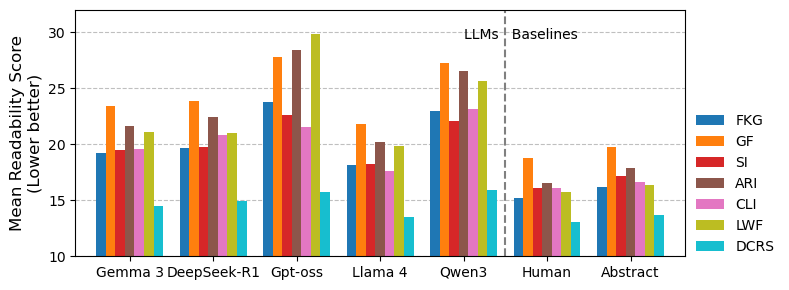

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Model': ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human', 'Abstract'],
    'FKG': [19.20, 19.69, 23.79, 18.13, 22.94, 15.25, 16.17],
    'GF': [23.46, 23.85, 27.82, 21.80, 27.27, 18.79, 19.75],
    'SI': [19.52, 19.76, 22.61, 18.25, 22.05, 16.13, 17.18],
    'ARI': [21.68, 22.47, 28.45, 20.22, 26.52, 16.58, 17.91],
    'CLI': [19.55, 20.80, 21.55, 17.58, 23.15, 16.08, 16.61],
    'LWF': [21.12, 21.02, 29.90, 19.86, 25.70, 15.70, 16.38],
    'DCRS': [14.48, 14.94, 15.77, 13.54, 15.94, 13.05, 13.65]
}

df = pd.DataFrame(data)
df = df.set_index('Model')

fig, ax = plt.subplots(figsize=(8, 3))

df.plot(kind='bar', ax=ax, width=0.8, colormap='tab10')

ax.set_ylabel('Mean Readability Score\n(Lower better)', fontsize=12)

ax.set_xlabel('', fontsize=12)
ax.set_ylim(10, 32)

plt.xticks(rotation=0, ha='center')

plt.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0., frameon=False)

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.5)
ax.set_axisbelow(True) # 确保网格线在条形图下方

separator_x = 4.5
ax.axvline(x=separator_x, color='grey', linestyle='--', linewidth=1.5)
ax.text(separator_x, ax.get_ylim()[1]*0.95, '        LLMs   Baselines ', ha='center', va='top')

plt.tight_layout()

# plt.savefig('readability_scores_chart.png', dpi=300, bbox_inches='tight')
plt.show()